# STAT9013 – Module Project
## Applied Machine Learning for Industrial Data Analysis
> **Arjun Krishna Krishnakumar**

> **Stiudent ID: R00276690**


## 1. Data Understanding & Preprocessing 

In [164]:
import warnings; 
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time
from scipy import stats
from scipy.stats import ttest_ind
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay, silhouette_score,
    average_precision_score
)
from imblearn.over_sampling import SMOTE
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='deep')
pass_clr, fail_clr = '#069e2d', '#bf0603'

In [165]:
#Helper Functions

def load_secom_data(data_path: str, labels_path: str)-> tuple:
    """
    To load SECOM sensor data and labels
    return (DataFrame, ndarray).
    """
    sensor_df = pd.read_csv(data_path, sep='\s+',header=None, na_values='NaN')
    sensor_df.columns = [f'sensor_{i+1}' for i in range(sensor_df.shape[1])]
    label_df= pd.read_csv(labels_path, sep='\s+', header=None,names=['outcome', 'timestamp'])
    target = (label_df['outcome'] == 1).astype(int).values   # 1=Fail, 0=Pass
    return sensor_df, target


def preprocess_data(secom_data_raw: pd.DataFrame, missing_thresh: float = 0.50) -> pd.DataFrame:
    """Drop constant/high-missing cols, median-impute, remove post-impute zero-variance cols."""
    cleaned = secom_data_raw.copy()
    cleaned.drop(columns=cleaned.columns[cleaned.nunique(dropna=False) <= 1], inplace=True)
    cleaned.drop(columns=cleaned.columns[cleaned.isnull().mean() > missing_thresh], inplace=True)
    cleaned.fillna(cleaned.median(), inplace=True)
    cleaned.drop(columns=cleaned.columns[cleaned.std() == 0],inplace=True)
    return cleaned


def scale_features(cleaned_sensor_data: pd.DataFrame) -> tuple:
    """
    Tofit StandardScaler
    """
    fitted_scaler = StandardScaler()
    scaled_array  = fitted_scaler.fit_transform(cleaned_sensor_data)
    return scaled_array, fitted_scaler


def get_top_discriminating_features(secom_data_raw: pd.DataFrame, target: np.ndarray,top_n: int = 8) -> list:
    """
    To return top_n feature names most separating Pass/Fail by Welch t-test statistic.
    return List
    """
    t_scores = {
        col: abs(ttest_ind(secom_data_raw[col][target == 0],
                           secom_data_raw[col][target == 1],
                           equal_var=False).statistic)
        for col in secom_data_raw.columns
    }
    return sorted(t_scores, key=t_scores.get, reverse=True)[:top_n]


def evaluate_classifier(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """To return accuracy, precision,recall,F1-fail F1-macro for corresponding classifier."""
    return {
        'Model':            name,
        'Accuracy':         round(accuracy_score(y_true, y_pred), 4),
        'Precision (Fail)': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall (Fail)':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 (Fail)':        round(f1_score(y_true, y_pred, zero_division=0), 4),
        'F1 (Macro)':       round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'AUC-PR':           round(average_precision_score(y_true, y_pred), 4),
    }

In [166]:
#load data
dir_path     = "/Users/arjun/Documents/data mining/Data-mining-assignment-2/secom"
sensor_df,target = load_secom_data(
    os.path.join(dir_path, 'secom.data'),
    os.path.join(dir_path, 'secom_labels.data')
)

print(f"Raw shape: {sensor_df.shape}")
print(f"Pass: {(target==0).sum()}  |  Fail: {(target==1).sum()}  |  Fail rate: {target.mean()*100:.1f}%")



Raw shape: (1567, 590)
Pass: 1463  |  Fail: 104  |  Fail rate: 6.6%


Sensors with any missing values : 538
Sensors with more than 50%  missing: 28
Total missing data(cells): 41,951


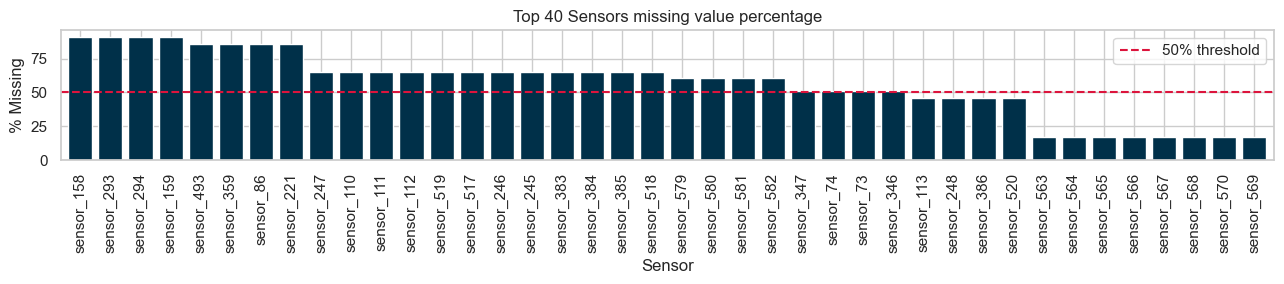

In [194]:
#missing value detection
missing_percentage = sensor_df.isnull().mean() * 100
print(f"Sensors with any missing values : {(missing_percentage > 0).sum()}")
print(f"Sensors with more than 50%  missing: {(missing_percentage > 50).sum()}")
print(f"Total missing data(cells): {sensor_df.isnull().sum().sum():,}")

fig,ax = plt.subplots(figsize=(13, 3))
missing_percentage.sort_values(ascending=False).head(40).plot.bar(ax=ax, color='#003049', width=0.8)
ax.axhline(50, color='crimson', ls='--', lw=1.5, label='50% threshold')
ax.set(title='Top 40 Sensors missing value percentage', ylabel='% Missing', xlabel='Sensor')
ax.legend()
plt.tight_layout();
plt.savefig('sensor_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()

In [168]:
#Preprocessing and scaling
cleaned_data = preprocess_data(sensor_df, missing_thresh=0.50)
features_scaled, std_scaler = scale_features(cleaned_data)

print(f"Sensors before preprocessing : {sensor_df.shape[1]}")
print(f"Sensors after  preprocessing : {cleaned_data.shape[1]}")
print(f"Samples                      : {features_scaled.shape[0]}")
print(f"Remaining missing cells      : {np.isnan(features_scaled).sum()}")

Sensors before preprocessing : 590
Sensors after  preprocessing : 446
Samples                      : 1567
Remaining missing cells      : 0



## 2. Exploratory Data Analysis

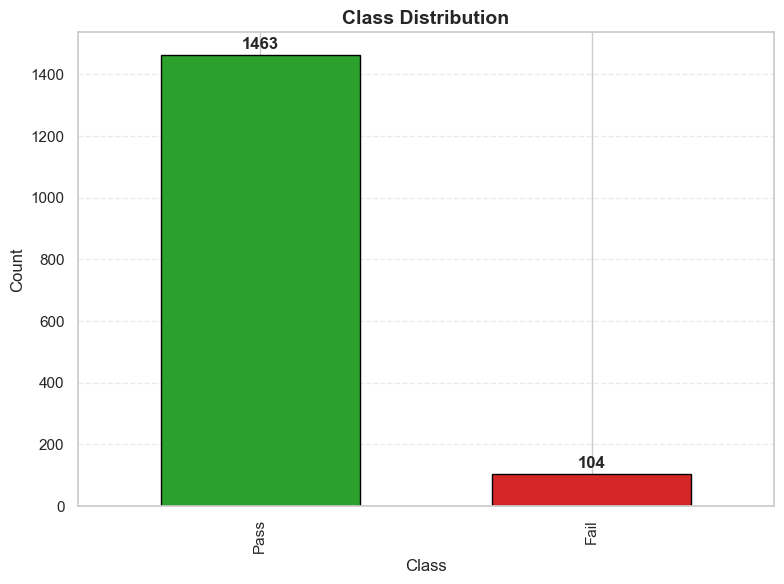

In [195]:
#Class imbalance chart
fig, axes = plt.subplots(figsize=(8, 6))
class_counts = pd.Series(target).map({0: 'Pass', 1: 'Fail'}).value_counts()
class_counts.plot.bar(
    ax=axes,
    color=['#2CA02C', '#D62728'],
    edgecolor='black',
    width=0.6
)

for rect in axes.patches:
    axes.text(rect.get_x() + rect.get_width()/2,rect.get_height() + 20,f"{int(rect.get_height())}",ha='center',fontsize=12,fontweight='bold')

axes.set_title('Class Distribution', fontsize=14, fontweight='bold')
axes.set_xlabel('Class', fontsize=12)
axes.set_ylabel('Count', fontsize=12)
axes.tick_params(axis='both', labelsize=11)
axes.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

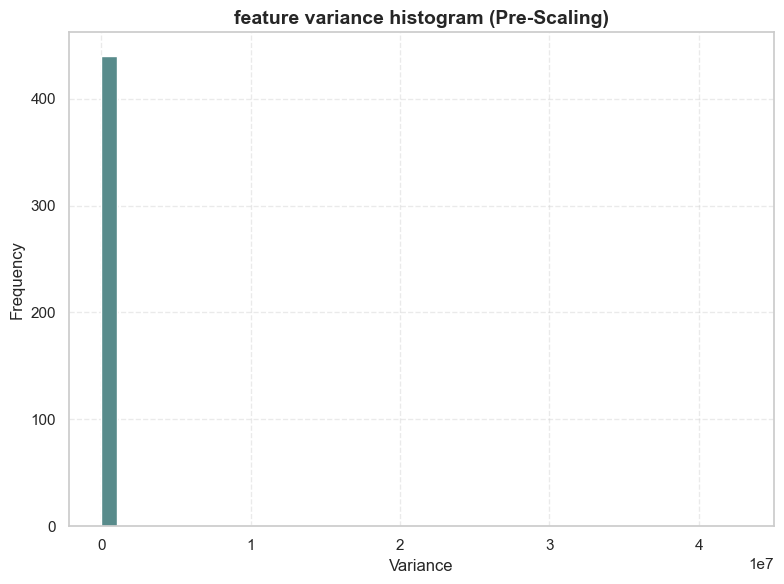

In [196]:
#feature variance histogram
fig, axes = plt.subplots(figsize=(8, 6))
feature_variances = cleaned_data.var().values
axes.hist(feature_variances,
    bins=40,color='#588b8b',edgecolor='white')
axes.set_title('feature variance histogram (Pre-Scaling)',fontsize=14,fontweight='bold')
axes.set_xlabel('Variance', fontsize=12)
axes.set_ylabel('Frequency', fontsize=12)
axes.tick_params(axis='both', labelsize=11)
axes.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('feature_variance.png', dpi=300, bbox_inches='tight')
plt.show()

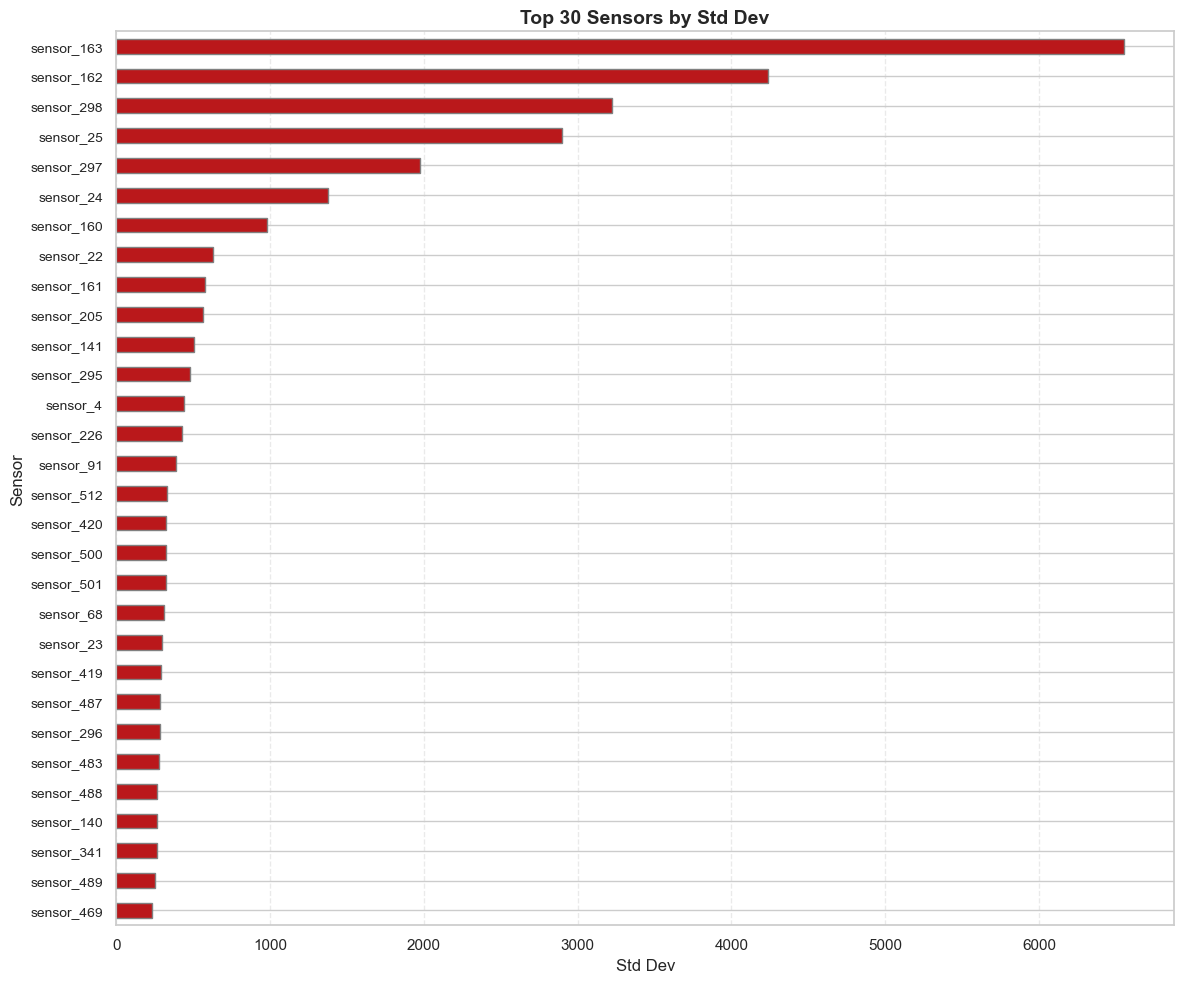

In [199]:
#standard deviation of top 30 sensors
fig, ax = plt.subplots(figsize=(12, 10))
top_sensors = cleaned_data.std().nlargest(30).sort_values()
top_sensors.plot.barh( ax=ax,color='#ba181b',edgecolor='grey')
ax.set_title('Top 30 Sensors by Std Dev',fontsize=14,fontweight='bold')
ax.set_xlabel('Std Dev', fontsize=12)
ax.set_ylabel('Sensor', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=11)
ax.margins(y=0.01)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('top_30.png', dpi=300, bbox_inches='tight')
plt.show()

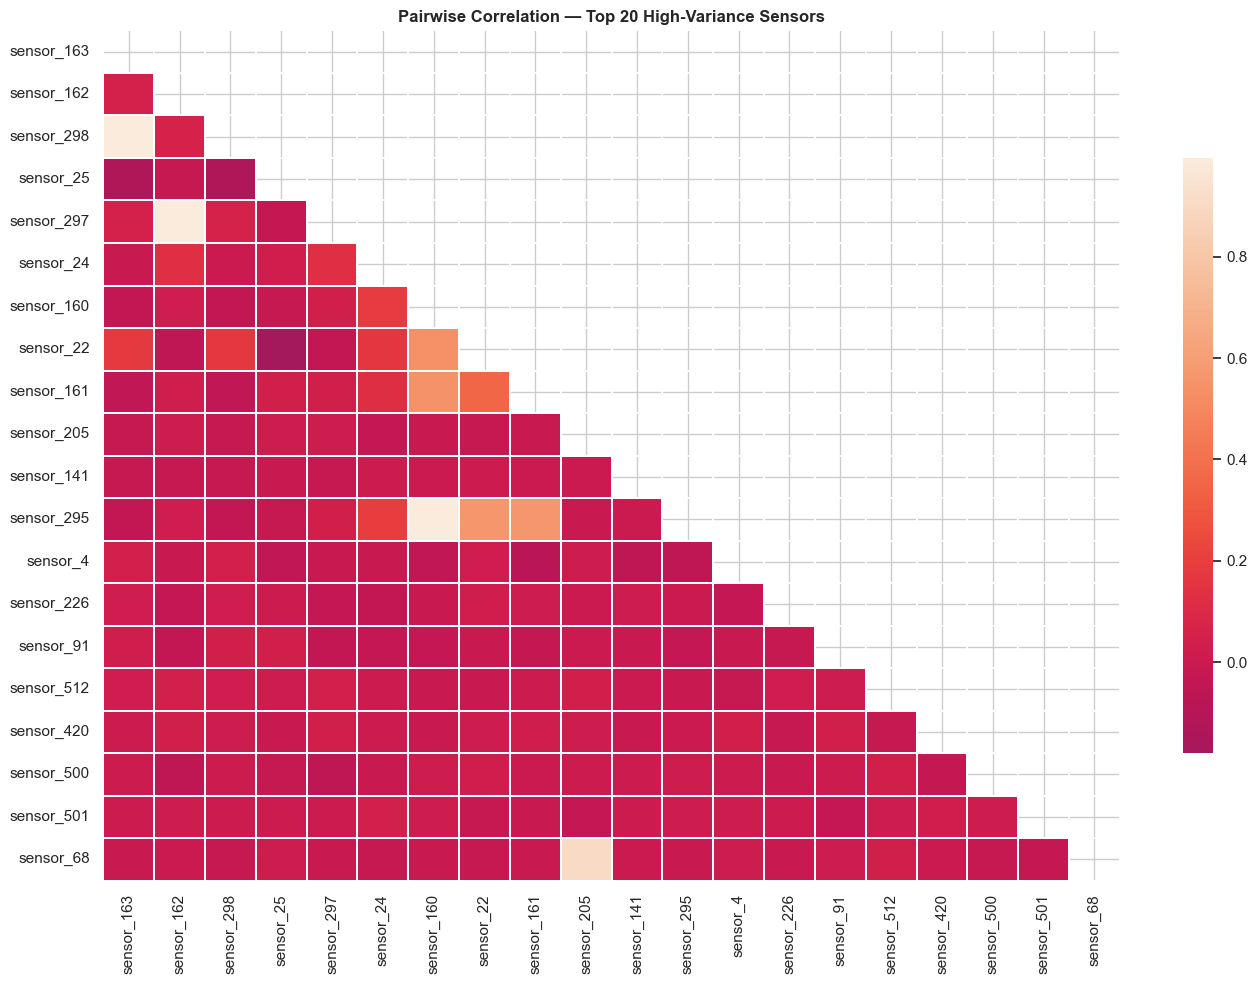

In [200]:
#correlation Heatmap fpr top 20 high-variance sensors
top20_sensors = cleaned_data.std().nlargest(20).index
corr_matrix =cleaned_data[top20_sensors].corr()
mask_upper= np.triu(np.ones((20, 20), dtype=bool))
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, mask=mask_upper,cmap='rocket', center=0,
            linewidths=0.2, annot=False,ax=ax,cbar_kws={'shrink': 0.7})
ax.set_title('Pairwise Correlation — Top 20 High-Variance Sensors',fontsize=12, fontweight='bold')
plt.tight_layout(); 
plt.savefig('heat_map.png', dpi=300, bbox_inches='tight')
plt.show()

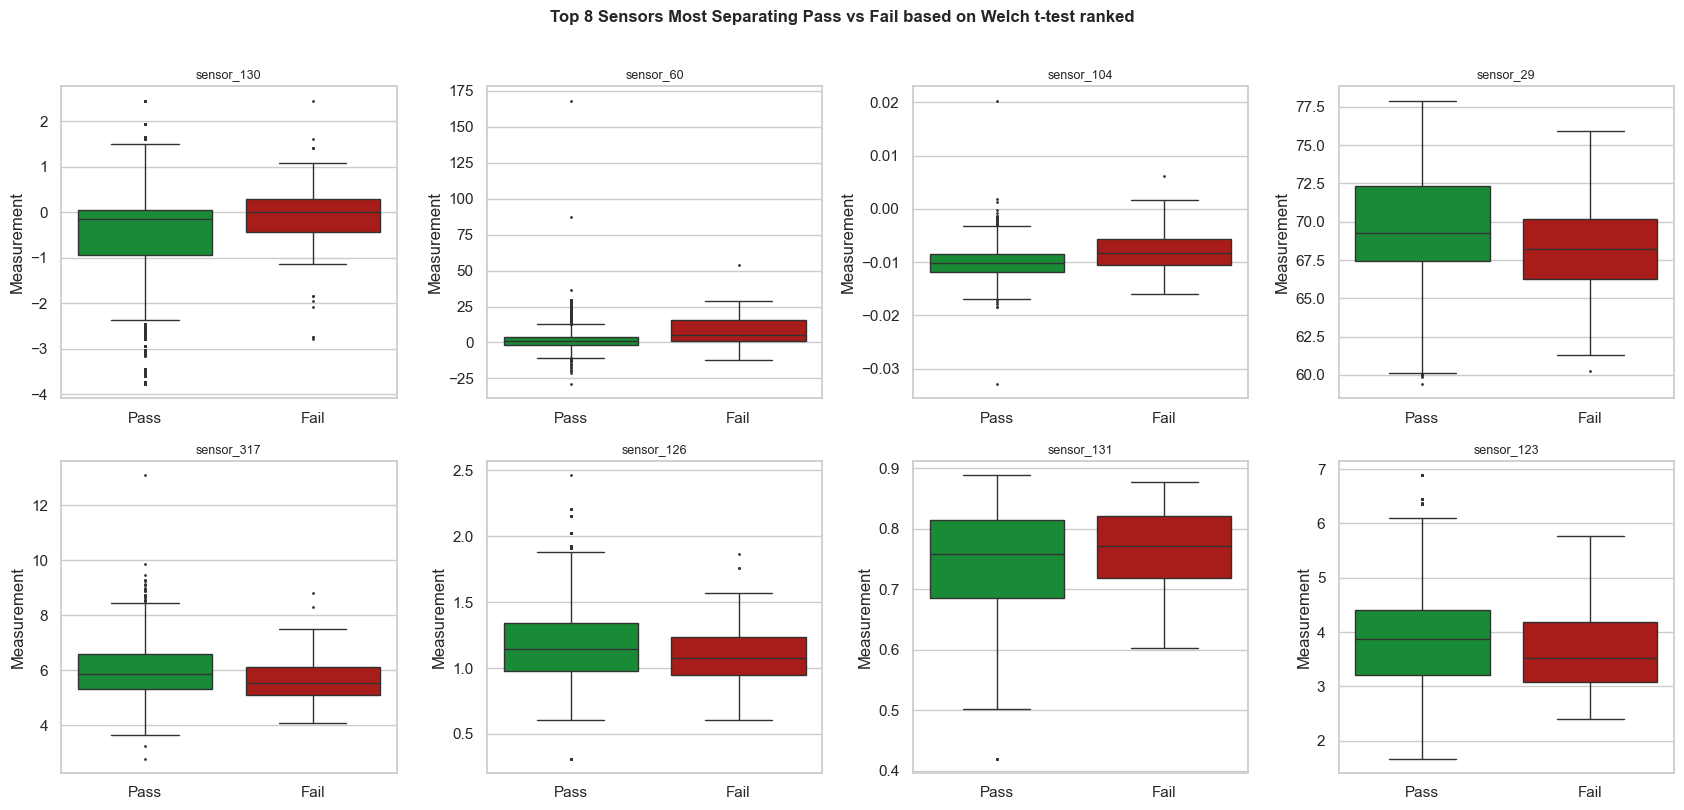

In [201]:
#top-8 discriminative sensors
top_discriminating = get_top_discriminating_features(cleaned_data, target, top_n=8)
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for ax, sensor_col in zip(axes.flatten(), top_discriminating):
    plot_data = pd.DataFrame({'Measurement':cleaned_data[sensor_col],'Outcome':np.where(target == 0,'Pass', 'Fail')})
    sns.boxplot(x='Outcome', y='Measurement',data=plot_data,palette={'Pass': pass_clr, 'Fail': fail_clr},flierprops=dict(marker='.', markersize=2), ax=ax)
    ax.set_title(sensor_col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Top 8 Sensors Most Separating Pass vs Fail based on Welch t-test ranked',fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); 
plt.savefig('box_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Outlier Analysis

In [174]:
#Z-Score, to count how many features per sample exceed 3 standard deviations
abs_z_matrix = np.abs(stats.zscore(features_scaled))
z_outlier_count = (abs_z_matrix > 3).sum(axis=1)
print("Z-Score Analysis (threshold = 3):")
print(f" Samples with >= 1 outlier sensor : {(z_outlier_count > 0).sum()}")
print(f" ßMean outlier sensors per sample: {z_outlier_count.mean():.2f}")
print(f" Pass mean: {z_outlier_count[target==0].mean():.2f}  ")
print(f" Fail mean: {z_outlier_count[target==1].mean():.2f} " )

Z-Score Analysis (threshold = 3):
 Samples with >= 1 outlier sensor : 1280
 ßMean outlier sensors per sample: 3.96
 Pass mean: 3.83  
 Fail mean: 5.69 


In [175]:
# IQR
features_df_temp = pd.DataFrame(features_scaled, columns=cleaned_data.columns)
q1_vals = features_df_temp.quantile(0.25)
q3_vals = features_df_temp.quantile(0.75)
iqr_range = q3_vals - q1_vals
lower_fence = q1_vals - 1.5 * iqr_range
upper_fence = q3_vals + 1.5 * iqr_range
iqr_outlier_count = ((features_df_temp < lower_fence) | (features_df_temp > upper_fence)).sum(axis=1)
print("IQR Analysis")
print(f"samples with outliers : {(iqr_outlier_count > 0).sum()}")
print(f"Average outliers/sample: {iqr_outlier_count.mean():.2f}")

IQR Analysis
samples with outliers : 1567
Average outliers/sample: 17.08


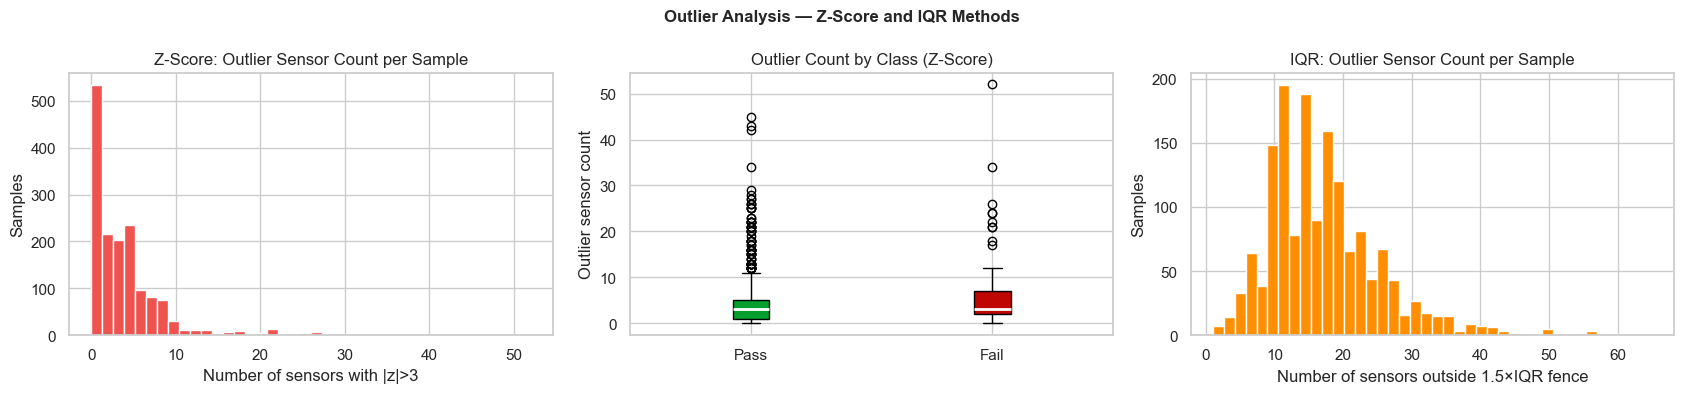

In [202]:
#outlier visualisation
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(z_outlier_count, bins=40, color='#EF5350', edgecolor='white')
axes[0].set(title='Z-Score: Outlier Sensor Count per Sample',xlabel='Number of sensors with |z|>3', ylabel='Samples')
#z-score count by class
bp = axes[1].boxplot(
    [z_outlier_count[target == 0], z_outlier_count[target == 1]],
    labels=['Pass', 'Fail'], patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)
for patch, colour in zip(bp['boxes'], [pass_clr, fail_clr]):
    patch.set_facecolor(colour)
axes[1].set(title='Outlier Count by Class (Z-Score)',ylabel='Outlier sensor count')
#IQR count distribution
axes[2].hist(iqr_outlier_count, bins=40, color='#FF8F00', edgecolor='white')
axes[2].set(title='IQR: Outlier Sensor Count per Sample',xlabel='Number of sensors outside 1.5×IQR fence', ylabel='Samples')
plt.suptitle('Outlier Analysis — Z-Score and IQR Methods', fontsize=12, fontweight='bold')
plt.savefig('Three_panel_outlier.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()



## 4. Dimensionality Reduction

In [177]:
#fit pca
pca_model = PCA(random_state=42).fit(features_scaled)
cumulative_variance = np.cumsum(pca_model.explained_variance_ratio_)
explained_variance_ratio = pca_model.explained_variance_ratio_
nc_90 = int(np.searchsorted(cumulative_variance, 0.90)) + 1
nc_95 = int(np.searchsorted(cumulative_variance, 0.95)) + 1
nc_99 = int(np.searchsorted(cumulative_variance, 0.99)) + 1
print(f"Components needed for 90% variance : {nc_90}")
print(f"Components needed for 95% variance : {nc_95}")
print(f"Components needed for 99% variance : {nc_99}")
print(f"\nFirst 10 individual explained variance ratios:")
for idx, val in enumerate(explained_variance_ratio[:10], 1):
    print(f"  PC{idx:>2}:{val*100:.2f}%")

Components needed for 90% variance : 129
Components needed for 95% variance : 162
Components needed for 99% variance : 216

First 10 individual explained variance ratios:
  PC 1:5.73%
  PC 2:3.86%
  PC 3:2.99%
  PC 4:2.68%
  PC 5:2.19%
  PC 6:2.08%
  PC 7:1.93%
  PC 8:1.90%
  PC 9:1.71%
  PC10:1.54%


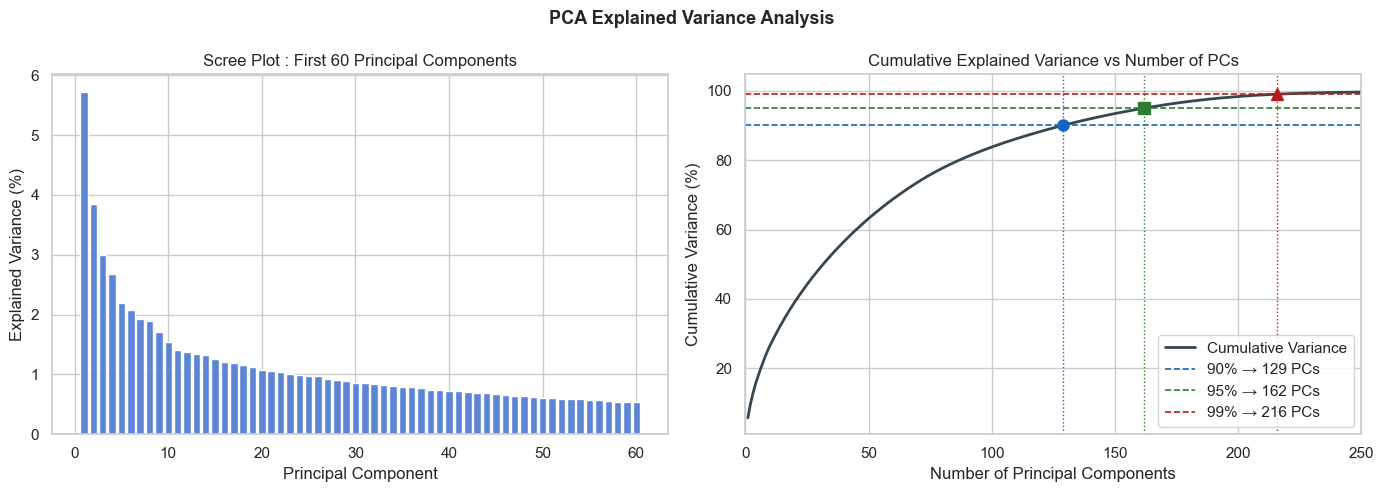

In [203]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#scree plot(first 60 PCs)
axes[0].bar(range(1, 61), explained_variance_ratio[:60] * 100, color='#5C85D6', width=0.8)
axes[0].set(title='Scree Plot : First 60 Principal Components',
            xlabel='Principal Component', ylabel='Explained Variance (%)')

# Cumulative variance with thresholds
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance * 100,color='#37474F', lw=2, label='Cumulative Variance')
threshold_info = [(nc_90, 90, '#1565C0', 'o'), (nc_95, 95, '#2E7D32', 's'), (nc_99, 99, '#B71C1C', '^')]
for nc, pct, col, mk in threshold_info:
    axes[1].axhline(pct, color=col, ls='--', lw=1.2, label=f'{pct}% → {nc} PCs')
    axes[1].axvline(nc, color=col, ls=':', lw=1.0)
    axes[1].plot(nc, pct, marker=mk, color=col, ms=8, zorder=5)
axes[1].set(title='Cumulative Explained Variance vs Number of PCs',
            xlabel='Number of Principal Components', ylabel='Cumulative Variance (%)',xlim=(0, 250))
axes[1].legend()

plt.suptitle('PCA Explained Variance Analysis', fontsize=13, fontweight='bold')
plt.savefig('screeplot.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

        PC1       PC2
0 -1.752366  2.843997
1 -2.275135  0.726532
2  0.105301  0.965564
3  1.112449  5.173058
4  0.808526  2.436766

shape reduced: 446 sensors => 162 PCs
Variance retained : 94.94%


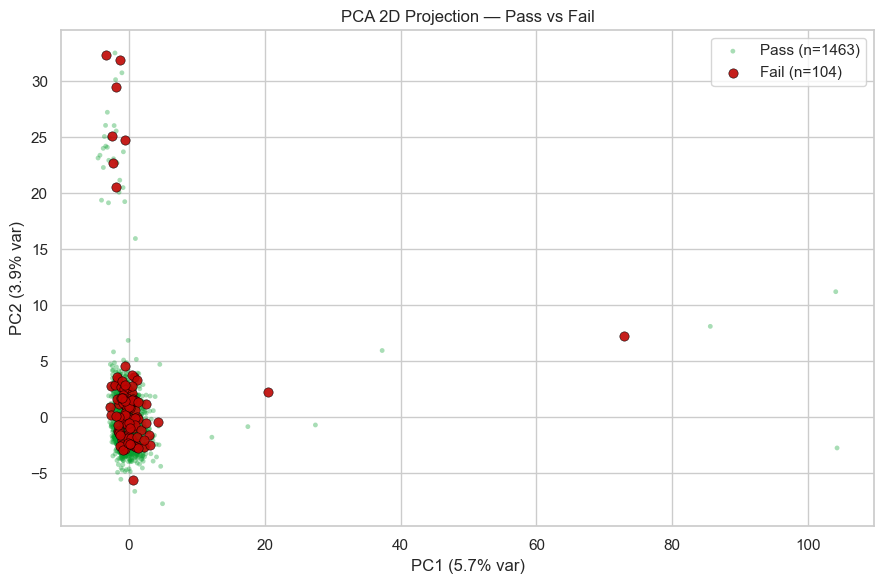

In [204]:
#PCA: 95% variance
pca_model    = PCA(n_components=nc_95, random_state=42)
features_pca = pca_model.fit_transform(features_scaled)
pca_2d = PCA(n_components=2, random_state=42)
scores_2d = pca_2d.fit_transform(features_scaled)
scores_df = pd.DataFrame(scores_2d, columns=['PC1', 'PC2'])
print(scores_df.head())
print(f"\nshape reduced: {features_scaled.shape[1]} sensors => {features_pca.shape[1]} PCs")
print(f"Variance retained : {pca_model.explained_variance_ratio_.sum()*100:.2f}%")

#scatterplot
fig, ax = plt.subplots(figsize=(9, 6))
for cls_val, cls_lbl, col, sz, alpha in [
        (0, 'Pass', pass_clr, 12, 0.35), (1, 'Fail', fail_clr, 45, 0.90)]:
    mask = target == cls_val
    ax.scatter(scores_2d[mask, 0], scores_2d[mask, 1], c=col, label=f'{cls_lbl} (n={mask.sum()})',
               s=sz, alpha=alpha, edgecolors='black' if cls_val==1 else 'none', lw=0.4)
ax.set(title='PCA 2D Projection — Pass vs Fail',
       xlabel=f'PC1 ({explained_variance_ratio[0]*100:.1f}% var)',
       ylabel=f'PC2 ({explained_variance_ratio[1]*100:.1f}% var)')
ax.legend()
plt.tight_layout(); 
plt.savefig('pca.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Clustering

In [205]:
k_range = range(2, 11)
inertia = []
silhouette = []
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(features_pca)
    
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(features_pca, labels, sample_size=600))

best_k = k_range[np.argmax(silhouette)]
optimal_k = best_k
k_search_range = k_range
inertia_vals = inertia
sil_vals = silhouette

results = pd.DataFrame({
    "k": k_range,
    "inertia": inertia,
    "silhouette": silhouette
})

print(results.to_string(index=False))
print(f"\nBest k by silhouette: {best_k}")

 k       inertia  silhouette
 2 629212.351696    0.787377
 3 615518.232906    0.031396
 4 589550.585847    0.038093
 5 581030.459482    0.024497
 6 562404.728982    0.002265
 7 562394.104263    0.016559
 8 542849.731004    0.009010
 9 540999.845101    0.029061
10 530701.669108    0.012126

Best k by silhouette: 2


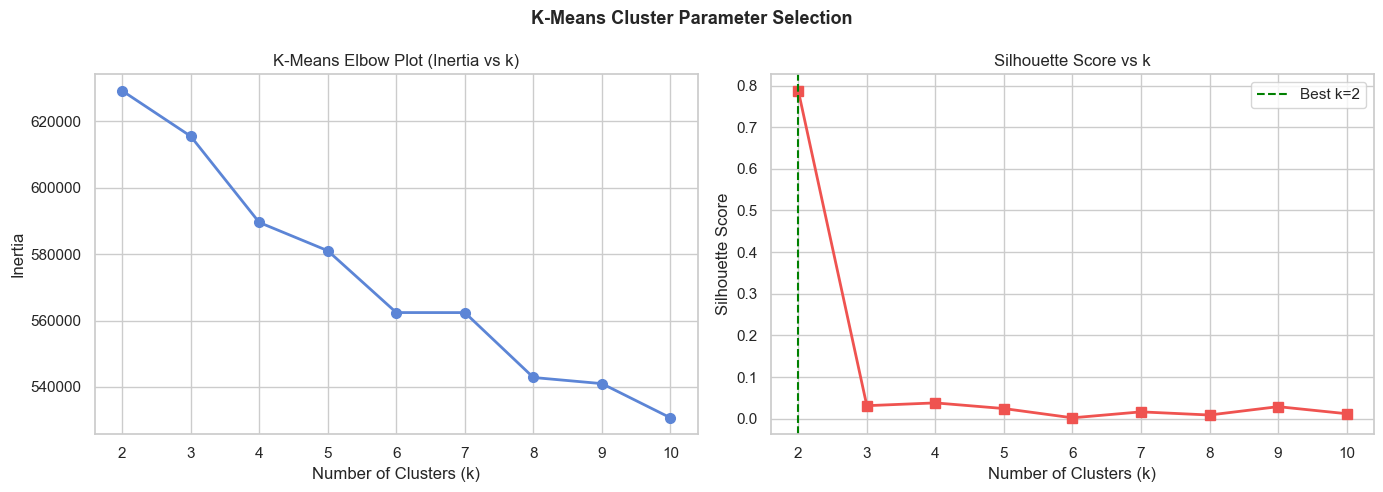

In [206]:
#Elbow and Silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_search_range), inertia_vals, 'o-',color='#5C85D6', lw=2, ms=7)
axes[0].set(title='K-Means Elbow Plot (Inertia vs k)',xlabel='Number of Clusters (k)', ylabel='Inertia')
axes[0].set_xticks(list(k_search_range))
axes[1].plot(list(k_search_range), sil_vals, 's-', color='#EF5350', lw=2, ms=7)
axes[1].axvline(optimal_k, color='green', ls='--', lw=1.5, label=f'Best k={optimal_k}')
axes[1].set(title='Silhouette Score vs k',xlabel='Number of Clusters (k)', ylabel='Silhouette Score')
axes[1].set_xticks(list(k_search_range))
axes[1].legend()

plt.suptitle('K-Means Cluster Parameter Selection', fontsize=13, fontweight='bold')
plt.savefig('elbow_plot.png', dpi=300, bbox_inches='tight')
plt.tight_layout() 
plt.show()

Final K-Means,k=2 and Silhouette:0.7077


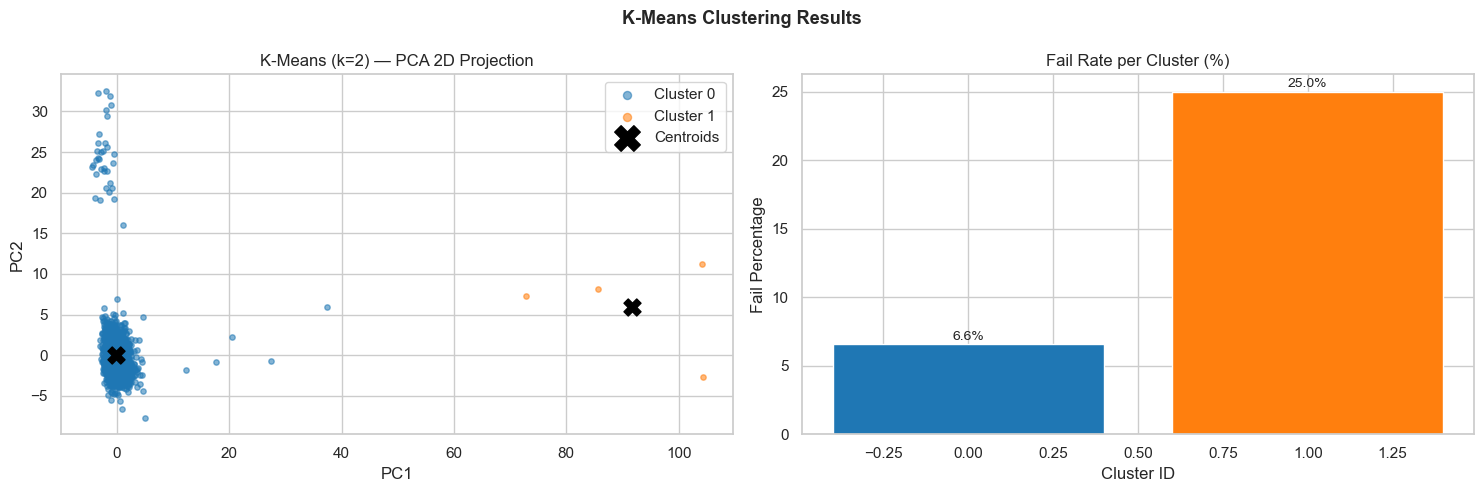


Cluster Composition:
  Cluster 0: 1563 samples | Pass=1460 | Fail=103 | Fail%=6.6%
  Cluster 1:    4 samples | Pass=3 | Fail=1 | Fail%=25.0%


In [207]:
#k-means with the optimal k
means_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_assignments = means_model.fit_predict(features_pca)
final_sil = silhouette_score(features_pca, km_assignments, sample_size=600, random_state=42)
print(f"Final K-Means,k={optimal_k} and Silhouette:{final_sil:.4f}")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

palette_km = sns.color_palette('tab10', optimal_k)
for c_idx in range(optimal_k):
    cluster_mask = km_assignments == c_idx
    axes[0].scatter(scores_2d[cluster_mask, 0], scores_2d[cluster_mask, 1],
                    c=[palette_km[c_idx]], label=f'Cluster {c_idx}',alpha=0.55, s=15)

centroids_2d = pca_2d.transform(pca_model.inverse_transform(means_model.cluster_centers_))
axes[0].scatter(centroids_2d[:, 0], centroids_2d[:, 1],marker='X', c='black', s=150, zorder=10, label='Centroids')
axes[0].set(title=f'K-Means (k={optimal_k}) — PCA 2D Projection',xlabel='PC1', ylabel='PC2')
axes[0].legend(markerscale=1.5)

#fail-rate per cluster
cluster_fail_pct = [
    target[km_assignments == c_idx].mean() * 100
    for c_idx in range(optimal_k)
]

bar_colours = [palette_km[i] for i in range(optimal_k)]
axes[1].bar(range(optimal_k), cluster_fail_pct, color=bar_colours, edgecolor='white')
for bar_idx, pct_val in enumerate(cluster_fail_pct):
    axes[1].text(bar_idx, pct_val + 0.3, f'{pct_val:.1f}%', ha='center', fontsize=10)
axes[1].set(title='Fail Rate per Cluster (%)',xlabel='Cluster ID', ylabel='Fail Percentage')
plt.suptitle('K-Means Clustering Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('k_means.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCluster Composition:")
for c_idx in range(optimal_k):
    n_total = (km_assignments == c_idx).sum()
    n_fail  = target[km_assignments == c_idx].sum()
    print(f"  Cluster {c_idx}: {n_total:4d} samples | "
          f"Pass={n_total-n_fail} | Fail={n_fail} | Fail%={cluster_fail_pct[c_idx]:.1f}%")

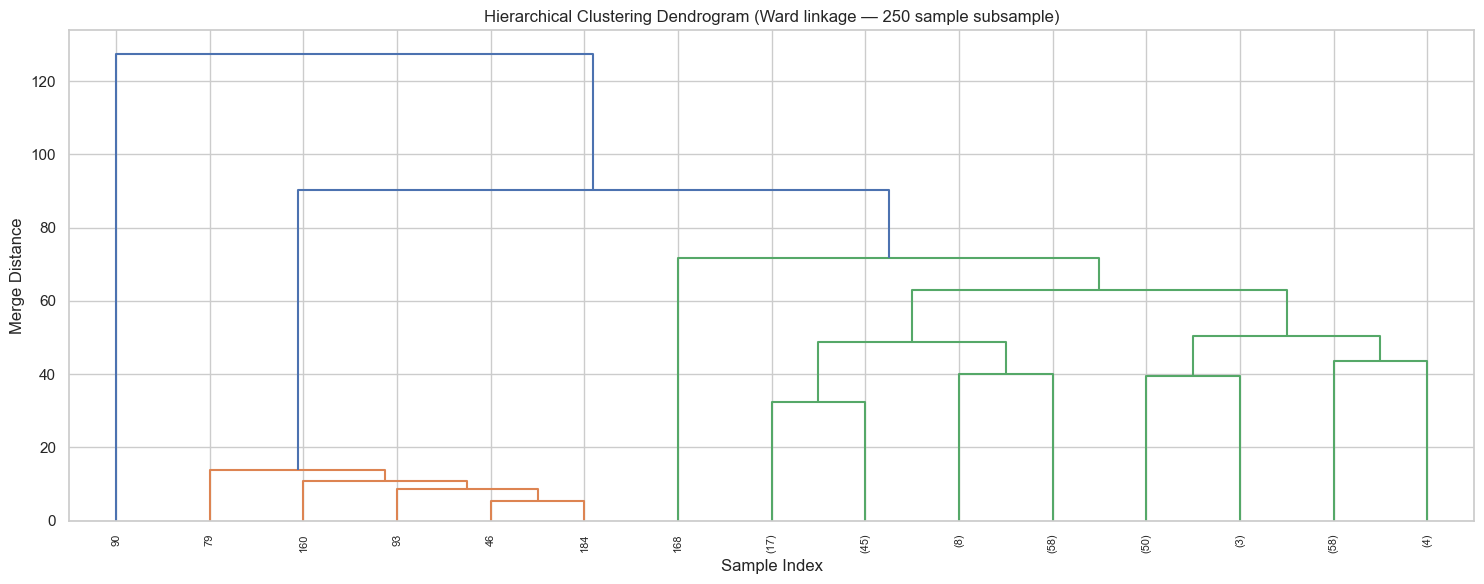

In [208]:
#Hierarchical Clustering, sub sample 250
np.random.seed(42)
subsample_idx  = np.random.choice(len(features_pca), size=250, replace=False)
X_sub_hier  = features_pca[subsample_idx, :15]   #subsampled, first 15 pcs
linkage_matrix = linkage(X_sub_hier, method='ward')

fig, ax = plt.subplots(figsize=(15, 6))
dendrogram(linkage_matrix, ax=ax, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7 * max(linkage_matrix[:, 2]))
ax.set(title='Hierarchical Clustering Dendrogram (Ward linkage — 250 sample subsample)',
       xlabel='Sample Index', ylabel='Merge Distance')
plt.tight_layout()
plt.savefig('ward_linkage_dendogram.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Classification

In [184]:
#train / test split + SMOTE Balancing
X_train, X_test, y_train, y_test = train_test_split(
    features_pca,target,test_size=0.2,stratify=target,random_state=42
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Dataset split summary:\n")
print(f"Train(orginal): {len(X_train):4d} and "f"Pass={(y_train==0).sum()} Fail={(y_train==1).sum()}")
print(f"Train (SMOTE): {len(X_train_bal):4d} and "f"Pass={(y_train_bal==0).sum()} Fail={(y_train_bal==1).sum()}")
print(f"Test(unchanged): {len(X_test):4d} and" f"Pass={(y_test==0).sum()} Fail={(y_test==1).sum()}")
X_tr_sm, y_tr_sm = X_train_bal, y_train_bal
X_te, y_te = X_test, y_test

Dataset split summary:

Train(orginal): 1253 and Pass=1170 Fail=83
Train (SMOTE): 2340 and Pass=1170 Fail=1170
Test(unchanged):  314 andPass=293 Fail=21


k-NN CV and Recall scores:
  k= 3 : Recall = 1.0000
  k= 5 : Recall = 0.9991
  k= 7 : Recall = 0.9991
  k= 9 : Recall = 0.9991
  k=11 : Recall = 1.0000
  k=13 : Recall = 1.0000
  k=15 : Recall = 1.0000
  k=17 : Recall = 1.0000
  k=19 : Recall = 1.0000
  k=21 : Recall = 1.0000
  k=23 : Recall = 1.0000
  k=25 : Recall = 0.9991
  k=27 : Recall = 0.9991
  k=29 : Recall = 0.9991


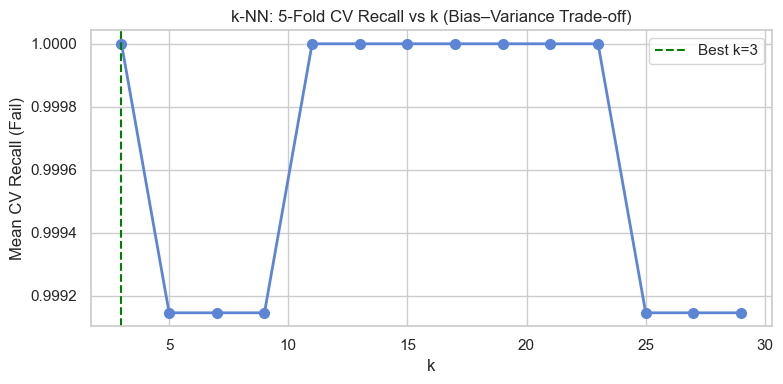


k-NN (k=3)— Test Classification Report:
              precision    recall  f1-score   support

        Pass       0.95      0.44      0.60       293
        Fail       0.08      0.67      0.14        21

    accuracy                           0.45       314
   macro avg       0.51      0.55      0.37       314
weighted avg       0.89      0.45      0.57       314



In [185]:
#k-Nearest Neighbours 
k_candidates = list(range(3, 30, 2))
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {'n_neighbors': k_candidates,'weights': ['uniform', 'distance']},
    cv=5, scoring='recall', n_jobs=-1
)
knn_grid.fit(X_tr_sm, y_tr_sm)
best_knn_k = knn_grid.best_params_['n_neighbors']
cv_f1_knn = [
    knn_grid.cv_results_['mean_test_score'][
        list(knn_grid.cv_results_['param_n_neighbors']).index(k)
    ]
    for k in k_candidates
]
print("k-NN CV and Recall scores:")
for kv, fv in zip(k_candidates, cv_f1_knn):
    marker =  ' <= selected' if kv == optimal_k else ''
    print(f"  k={kv:>2} : Recall = {fv:.4f}{marker}")

#f1 vs K plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_candidates, cv_f1_knn, 'o-', color='#5C85D6', lw=2, ms=7)
ax.axvline(best_knn_k, color='green', ls='--', lw=1.5, label=f'Best k={best_knn_k}')
ax.set(title='k-NN: 5-Fold CV Recall vs k (Bias–Variance Trade-off)',xlabel='k', ylabel='Mean CV Recall (Fail)')
ax.legend()
plt.tight_layout()
plt.show()

knn_clf = KNeighborsClassifier(n_neighbors=best_knn_k)
knn_clf.fit(X_tr_sm, y_tr_sm)
pred_knn = knn_clf.predict(X_te)

print(f"\nk-NN (k={best_knn_k})— Test Classification Report:")
print(classification_report(y_te, pred_knn, target_names=['Pass', 'Fail']))

In [186]:
#Decision Tree: Hyperparameter Tuning(max_depth) and Evaluation
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 3, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42), dt_param_grid,
    cv=5, scoring='f1_macro', n_jobs=-1
)
dt_grid.fit(X_tr_sm, y_tr_sm)
best_depth = dt_grid.best_params_['max_depth']
print("Best DT params:", dt_grid.best_params_)

cv_f1_scores = [
    dt_grid.cv_results_['mean_test_score'][
        list(dt_grid.cv_results_['param_max_depth']).index(d)
    ]
    for d in [3, 5, 7, 10, 15, None]
]
print("CV F1 scores by max_depth:")
depth_candidates = [3, 5, 7, 10, 15, None]
for d, score in zip(depth_candidates, cv_f1_scores):
    selected = " <- best" if d == best_depth else ""
    print(f"depth={str(d):>4} : {score:.4f}{selected}")
#final model
dt_model = dt_grid.best_estimator_
dt_model.fit(X_tr_sm, y_tr_sm)
y_pred = dt_model.predict(X_te)

print(f"\nTest Results (Decision Tree, max_depth={best_depth}):")
print(classification_report(y_te, y_pred, target_names=['Pass', 'Fail']))

Best DT params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1}
CV F1 scores by max_depth:
depth=   3 : 0.6811
depth=   5 : 0.7632
depth=   7 : 0.8123
depth=  10 : 0.8512
depth=  15 : 0.8670
depth=None : 0.8707 <- best

Test Results (Decision Tree, max_depth=None):
              precision    recall  f1-score   support

        Pass       0.94      0.86      0.90       293
        Fail       0.11      0.24      0.15        21

    accuracy                           0.82       314
   macro avg       0.52      0.55      0.52       314
weighted avg       0.88      0.82      0.85       314



In [187]:
#SVM
svm_params = { "C": loguniform(0.1, 100),"gamma": loguniform(1e-4, 1e-1),"kernel": ["rbf", "sigmoid"]}

svm_search = RandomizedSearchCV(
    SVC(class_weight="balanced", random_state=42),
    param_distributions=svm_params,
    n_iter=30,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

svm_search.fit(X_tr_sm, y_tr_sm)
best_params = svm_search.best_params_

print(
    f"Best SVM parameters: "
    f"C={best_params['C']:.4f}, "
    f"gamma={best_params['gamma']:.6f}, "
    f"kernel={best_params['kernel']}"
)

#Final tuned SVM model
svm_model = svm_search.best_estimator_

y_pred_svm = svm_model.predict(X_te)

print("\nTest Results (Tuned SVM):")
print(classification_report(y_te, y_pred_svm, target_names=["Pass", "Fail"]))

Best SVM parameters: C=89.0620, gamma=0.002514, kernel=rbf

Test Results (Tuned SVM):
              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
        Fail       0.50      0.05      0.09        21

    accuracy                           0.93       314
   macro avg       0.72      0.52      0.53       314
weighted avg       0.91      0.93      0.91       314



## 7. Model Evaluation

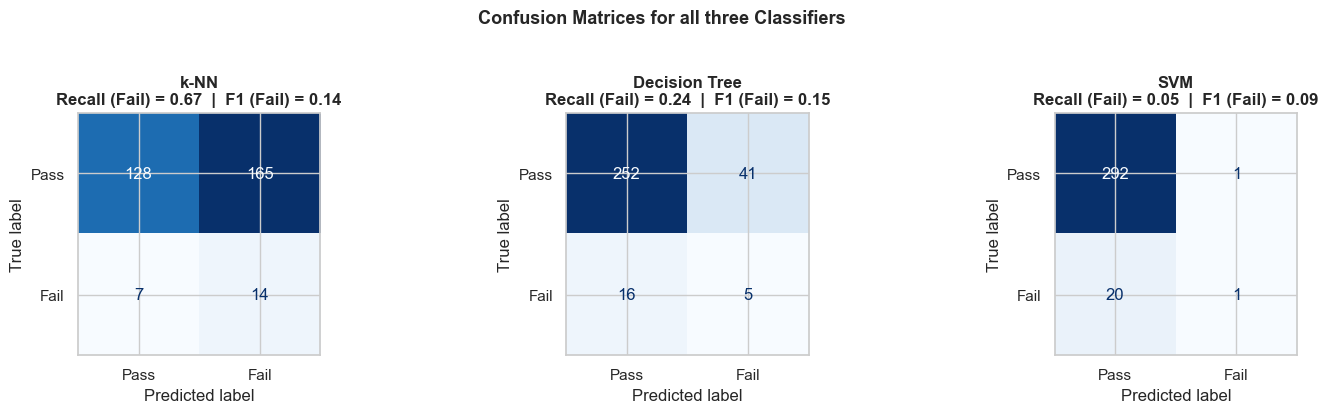

In [209]:
#Confusion Matrices
all_predictions = {'k-NN': pred_knn,'Decision Tree': y_pred, 'SVM': y_pred_svm}
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (model_name, y_predicted) in zip(axes, all_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_predicted,display_labels=['Pass', 'Fail'],ax=ax, colorbar=False, cmap='Blues')
    recall_val = recall_score(y_te, y_predicted, zero_division=0)
    f1_val = f1_score(y_te, y_predicted, zero_division=0)
    ax.set_title(f'{model_name}\nRecall (Fail) = {recall_val:.2f}  |  F1 (Fail) = {f1_val:.2f}', fontweight='bold')

plt.suptitle('Confusion Matrices for all three Classifiers', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [189]:
#comprehensive metrics table
metrics_rows = [
    evaluate_classifier(name, y_te, y_pred)
    for name, y_pred in all_predictions.items()
]
metrics_df = pd.DataFrame(metrics_rows).set_index('Model')

print("Model Comparison Table:")
print(metrics_df.to_string(float_format='{:.4f}'.format))

Model Comparison Table:
               Accuracy  Precision (Fail)  Recall (Fail)  F1 (Fail)  F1 (Macro)  AUC-PR
Model                                                                                  
k-NN             0.4522            0.0782         0.6667     0.1400      0.3691  0.0744
Decision Tree    0.8185            0.1087         0.2381     0.1493      0.5238  0.0768
SVM              0.9331            0.5000         0.0476     0.0870      0.5261  0.0875


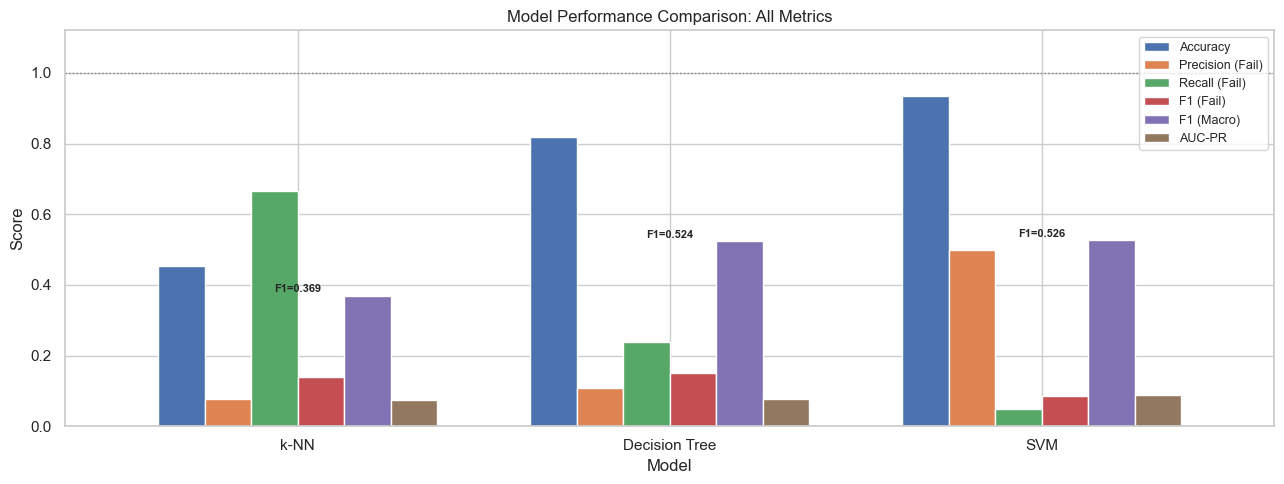

In [210]:
#mddel performance comparison bar chart
fig, ax = plt.subplots(figsize=(13, 5))
metrics_df.plot.bar(ax=ax, edgecolor='white', width=0.75)
ax.set(title='Model Performance Comparison: All Metrics',ylabel='Score', ylim=(0, 1.12))
ax.set_xticklabels(metrics_df.index,rotation=0)
ax.axhline(1.0, color='grey',ls=':',lw=1)
ax.legend(loc='upper right', fontsize=9)

for i, (row_name, row_vals) in enumerate(metrics_df.iterrows()):
    ax.text(i, row_vals['F1 (Macro)'] + 0.01,f"F1={row_vals['F1 (Macro)']:.3f}", ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [191]:
#5-Fold Cross-Validation Comparison
print("5-Fold CV F1(macro) on balanced training data:\n")
results = {}
models = {
    'k-NN':          knn_clf,
    'Decision Tree': dt_model,
    'SVM':           svm_model
}
for name, model in models.items():
    scores = cross_val_score(model, X_tr_sm, y_tr_sm, cv=5, scoring='f1_macro')
    results[name] = {'F1 mean': scores.mean(), 'F1 std': scores.std()}
    print(f"{name:15} | F1={scores.mean():.4f} ±{scores.std():.4f}")

5-Fold CV F1(macro) on balanced training data:

k-NN            | F1=0.6606 ±0.0298
Decision Tree   | F1=0.8784 ±0.0153
SVM             | F1=0.9944 ±0.0035


In [211]:
original_models = {
    "k-NN(original)":KNeighborsClassifier(n_neighbors=7),
    "Decision Tree(original)": DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    "SVM (original)": SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
}

tuned_predictions = {"k-NN (tuned)":pred_knn,
    "Decision Tree (tuned)": y_pred,
    "SVM (tuned)": y_pred_svm}

print(f"{'Model':<25} | {'Recall Fail':>11} | {'F1 Fail':>8} | {'F1 Macro':>8}")
print("-" * 62)

#original scores
for name, model in original_models.items():
    model.fit(X_tr_sm, y_tr_sm)
    pred = model.predict(X_te)
    f1_mac  = f1_score(y_te, pred, average='macro')
    f1_fail = f1_score(y_te, pred, zero_division=0)
    rec     = recall_score(y_te, pred, zero_division=0)
    print(f"{name:<25} | {f1_mac:>8.4f} | {f1_fail:>8.4f} |{rec:>11.4f}")
 
print("-" * 62)

#tuned scores
for name, pred in tuned_predictions.items():
    f1_mac  = f1_score(y_te, pred, average='macro')
    f1_fail = f1_score(y_te, pred, zero_division=0)
    rec     = recall_score(y_te, pred, zero_division=0)
    print(f"{name:<25} | {rec:>11.4f} | {f1_fail:>8.4f} | {f1_mac:>8.4f}")

Model                     | Recall Fail |  F1 Fail | F1 Macro
--------------------------------------------------------------
k-NN(original)            |   0.2919 |   0.1250 |     0.7143
Decision Tree(original)   |   0.4911 |   0.1524 |     0.3810
SVM (original)            |   0.5235 |   0.0833 |     0.0476
--------------------------------------------------------------
k-NN (tuned)              |      0.6667 |   0.1400 |   0.3691
Decision Tree (tuned)     |      0.2381 |   0.1493 |   0.5238
SVM (tuned)               |      0.0476 |   0.0870 |   0.5261
